# Week 1 - LLaVA Model Loading & First Inference

**Literature:**
- Liu et al. (2023) LLaVA - https://arxiv.org/abs/2304.08485
- Alayrac et al. (2022) Flamingo - https://arxiv.org/abs/2204.14198
- Radford et al. (2021) CLIP - https://arxiv.org/abs/2103.00020


In [ ]:
# CELL 1 - Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [ ]:
# CELL 2 - Install packages

!pip install -q --upgrade accelerate
!pip install -q sentencepiece

import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'show', 'transformers'],
    capture_output=True, text=True
)
for line in result.stdout.split('\n'):
    if line.startswith('Version'):
        print(f'transformers already installed: {line}')
        break

print('Packages ready.')
print('No restart needed — proceed directly to Cell 3.')

transformers already installed: Version: 5.13.1
Packages ready.
No restart needed — proceed directly to Cell 3.


In [ ]:
# CELL 3 - Set paths

import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'
MODEL_CACHE   = f'{MODELS_DIR}/llava_cache'
N_SAMPLES     = 10

MODEL_ID = 'llava-hf/llava-v1.6-mistral-7b-hf'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

test_csv = f'{PROCESSED_DIR}/test.csv'
print('Path check:')
print(f'  test.csv    : {os.path.exists(test_csv)} -> {test_csv}')
print(f'  results/    : {os.path.exists(RESULTS_DIR)}')
print(f'  model cache : {os.path.exists(MODEL_CACHE)}')

if not os.path.exists(test_csv):
    print('\nERROR: test.csv missing — run week1_data_colab.ipynb first.')
else:
    print('\nPaths OK. Proceed to Cell 4.')

Path check:
  test.csv    : True -> /content/drive/MyDrive/dissertation_final/data/processed/test.csv
  results/    : True
  model cache : True

Paths OK. Proceed to Cell 4.


In [ ]:
# CELL 4 - Check GPU and VRAM

import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    cuda = torch.version.cuda
    print(f'GPU          : {name}')
    print(f'VRAM         : {vram:.1f} GB')
    print(f'CUDA version : {cuda}')
    print(f'torch        : {torch.__version__}')
    if vram >= 14:
        print('Status       : Sufficient VRAM for float16 LLaVA-7B.')
    elif vram >= 8:
        print('Status       : Marginal VRAM — will use aggressive memory saving.')
    else:
        print('WARNING      : Low VRAM — switch to Runtime -> T4 or A100 GPU.')
else:
    print('No GPU. Go to Runtime -> Change runtime type -> T4 GPU.')

GPU          : NVIDIA A100-SXM4-80GB
VRAM         : 85.1 GB
CUDA version : 12.8
torch        : 2.11.0+cu128
Status       : Sufficient VRAM for float16 LLaVA-7B.


In [ ]:
# CELL 5 - Import libraries

import os, pandas as pd, torch
from PIL import Image
from pathlib import Path

import transformers
print(f'transformers version : {transformers.__version__}')


transf_version = tuple(int(x) for x in transformers.__version__.split('.')[:2])

if transf_version >= (4, 38):

    from transformers import AutoProcessor, LlavaNextForConditionalGeneration
    USE_AUTO = True
    print('Using AutoProcessor (transformers >= 4.38)')
else:

    from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
    USE_AUTO = False
    print('Using LlavaNextProcessor (transformers < 4.38)')

print('All imports done.')

transformers version : 5.13.1
Using AutoProcessor (transformers >= 4.38)
All imports done.


In [ ]:
# CELL 6 - Load LLaVA

def load_llava():
    config_path = os.path.join(MODEL_CACHE, 'config.json')
    load_from   = MODEL_CACHE if os.path.exists(config_path) else MODEL_ID

    if load_from == MODEL_CACHE:
        print(f'Loading from Drive cache: {load_from}')
    else:
        print(f'Downloading from HuggingFace: {MODEL_ID}')
        print('First run — ~14GB download, takes 10-20 min...')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        free_vram = torch.cuda.mem_get_info()[0] / 1e9
        print(f'Free VRAM before load: {free_vram:.1f} GB')

    print('Loading processor...')
    if USE_AUTO:
        processor = AutoProcessor.from_pretrained(load_from)
    else:
        processor = LlavaNextProcessor.from_pretrained(
            load_from, use_fast=False
        )
    print('Processor ready.')

    print('Loading model in float16 (no bitsandbytes needed)...')
    model = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    model.eval()

    used_vram = (
        torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.mem_get_info()[0]
    ) / 1e9 if torch.cuda.is_available() else 0

    print(f'Model loaded on : {next(model.parameters()).device}')
    print(f'Model dtype     : {next(model.parameters()).dtype}')
    print(f'VRAM used       : {used_vram:.1f} GB')
    return processor, model

processor, model = load_llava()
print('\nLLaVA ready.')

Loading from Drive cache: /content/drive/MyDrive/dissertation_final/models/llava_cache
Free VRAM before load: 54.2 GB
Loading processor...
Processor ready.
Loading model in float16 (no bitsandbytes needed)...


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Model loaded on : cuda:0
Model dtype     : torch.float16
VRAM used       : 46.0 GB

LLaVA ready.


In [ ]:
# CELL 7 - Cache model to Drive

if not os.path.exists(os.path.join(MODEL_CACHE, 'config.json')):
    print(f'Caching model to Drive: {MODEL_CACHE}')
    os.makedirs(MODEL_CACHE, exist_ok=True)
    processor.save_pretrained(MODEL_CACHE)
    model.save_pretrained(MODEL_CACHE)
    size = sum(
        os.path.getsize(os.path.join(MODEL_CACHE, f))
        for f in os.listdir(MODEL_CACHE)
        if os.path.isfile(os.path.join(MODEL_CACHE, f))
    ) / 1e9
    print(f'Cached {size:.1f} GB to Drive. Future sessions load in ~30s.')
else:
    print('Model already cached in Drive. Skipping.')

Model already cached in Drive. Skipping.


In [ ]:
# CELL 8 - generate_caption()

def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conversation = [{
        'role': 'user',
        'content': [
            {'type': 'image'},
            {'type': 'text', 'text': prompt},
        ],
    }]
    text_input = processor.apply_chat_template(conversation, add_generation_prompt=True)
    inputs = processor(images=image, text=text_input, return_tensors='pt').to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
        )

    input_len = inputs['input_ids'].shape[1]
    caption   = processor.batch_decode(output_ids[:, input_len:], skip_special_tokens=True)[0]
    return caption.strip()

print('generate_caption() ready - used in all weeks 3-8.')

generate_caption() ready - used in all weeks 3-8.


Testing on one image...
Generated : In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. 

On the right side of the image, the player in the black jersey is seen running towards
Reference : Three people are playing with a red kick ball.


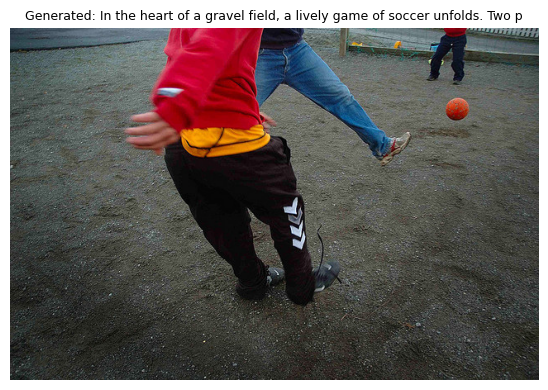

Single image test passed.


In [ ]:
# CELL 9 - Single image test

import matplotlib.pyplot as plt

test_df  = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
test_row = test_df.iloc[0]
test_img = Image.open(test_row['img_path']).convert('RGB')

print('Testing on one image...')
caption = generate_caption(processor, model, test_img)
ref     = test_row['captions'].split(' | ')[0]
print(f'Generated : {caption}')
print(f'Reference : {ref}')

fig, ax = plt.subplots(figsize=(6,4))
ax.imshow(test_img)
ax.set_title(f'Generated: {caption[:70]}', fontsize=9)
ax.axis('off')
plt.tight_layout()
plt.show()
print('Single image test passed.')

In [ ]:
# CELL 10 - Run inference on 10 test images

records = []
df = pd.read_csv(f'{PROCESSED_DIR}/test.csv').head(N_SAMPLES)

print('='*55)
print('Week 1 - LLaVA First Inference')
print('Literature: Liu et al. (2023); Alayrac et al. (2022)')
print('='*55)

for idx, (_, row) in enumerate(df.iterrows()):
    print(f'\n[{idx+1}/{N_SAMPLES}] {Path(row["img_path"]).name}')
    img  = Image.open(row['img_path']).convert('RGB')
    gen  = generate_caption(processor, model, img)
    refs = row['captions'].split(' | ')
    print(f'  Generated : {gen}')
    print(f'  Reference : {refs[0]}')
    records.append({
        'image_id':          row['image_id'],
        'img_path':          row['img_path'],
        'generated_caption': gen,
        'reference_1':       refs[0],
        'all_references':    row['captions'],
    })

results_df = pd.DataFrame(records)
print(f'\nDone. {len(results_df)} captions generated.')

Week 1 - LLaVA First Inference
Literature: Liu et al. (2023); Alayrac et al. (2022)

[1/10] 000000577864.jpg
  Generated : In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. 

On the right side of the image, the player in the black jersey is seen running towards
  Reference : Three people are playing with a red kick ball.

[2/10] 000000238013.jpg
  Generated : In the heart of the image, a man is captured in the midst of an intense game of tennis. He's dressed in a crisp white t-shirt and black shorts, his body poised in anticipation of the ball. His right hand grips a tennis racket, ready to strike, while his left hand is extended, fingers splayed in a gesture of balance and control.

The man is positioned on the left side 

In [ ]:
# CELL 11 - Save results to Drive

out = f'{RESULTS_DIR}/week1_first_inference.csv'
results_df.to_csv(out, index=False)
print(f'Saved to: {out}')
print(results_df[['image_id','generated_caption','reference_1']].to_string(index=False))

Saved to: /content/drive/MyDrive/dissertation_final/results/week1_first_inference.csv
 image_id                                                                                                                                                                                                                                                                                                                                                                                                                         generated_caption                                                    reference_1
   577864                  In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are caught in the midst of action. The player in the red jersey, positioned on the left side of the image, is in the process of kicking the ball, sending it flying towards the right side of the image. \n\nOn the right side of the image, the player in the black jersey is 

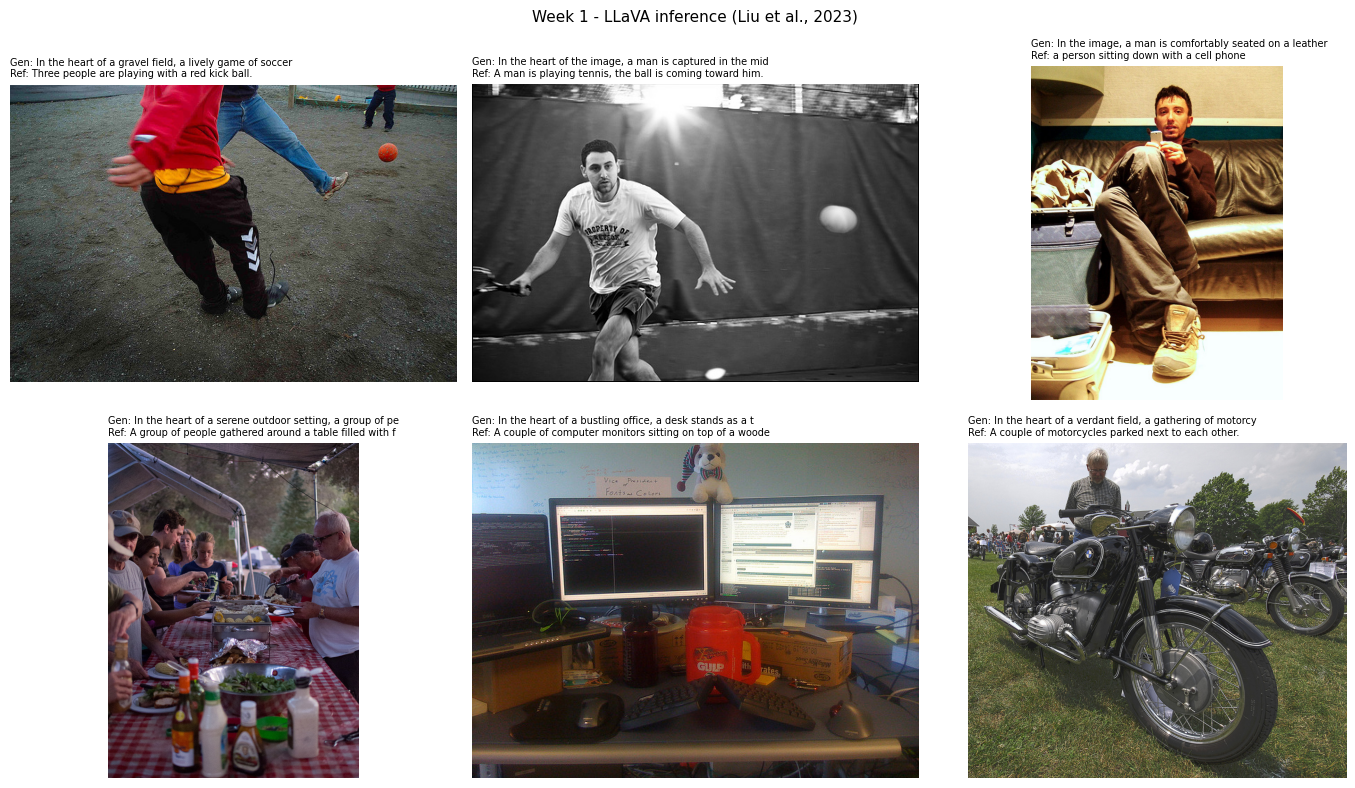

Grid saved to /content/drive/MyDrive/dissertation_final/results/week1_inference_grid.png


In [ ]:
# CELL 12 - Show grid

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, (_, row) in enumerate(results_df.head(6).iterrows()):
    img = Image.open(row['img_path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(
        f'Gen: {row["generated_caption"][:55]}\nRef: {row["reference_1"][:55]}',
        fontsize=7, loc='left'
    )
    axes[i].axis('off')
plt.suptitle('Week 1 - LLaVA inference (Liu et al., 2023)', fontsize=11)
plt.tight_layout()
path = f'{RESULTS_DIR}/week1_inference_grid.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grid saved to {path}')

In [ ]:
# CELL 13 - Final verification

print('='*55)
print('Week 1 - Final verification')
print('='*55)
for fpath in [
    f'{PROCESSED_DIR}/test.csv',
    f'{RESULTS_DIR}/week1_first_inference.csv',
    f'{RESULTS_DIR}/week1_inference_grid.png',
    f'{MODEL_CACHE}/config.json',
]:
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(fpath):40s} {size:>10,} bytes')

print()
print('Week 1 Model complete. Next: week2_explore_colab.ipynb')

Week 1 - Final verification
  [OK] test.csv                                     38,190 bytes
  [OK] week1_first_inference.csv                     8,404 bytes
  [OK] week1_inference_grid.png                  3,147,953 bytes
  [OK] config.json                                   1,946 bytes

Week 1 Model complete. Next: week2_explore_colab.ipynb
